Fundamental Matrix:
 [[-2.34679326e-20  1.47058824e-04  1.60246266e-01]
 [-1.47058824e-04 -2.97428290e-20  2.60246266e-01]
 [-1.61716854e-01 -2.61716854e-01  1.00000000e+00]]


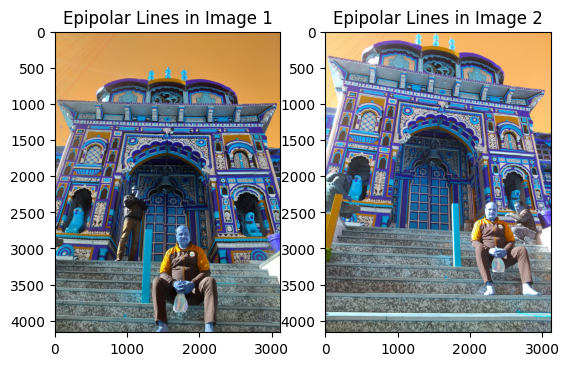

Epipole in Image 1: [ 1.76967461e+03 -1.08967461e+03  1.00000000e+00]
Epipole in Image 2: [ 1.77967461e+03 -1.09967461e+03  1.00000000e+00]


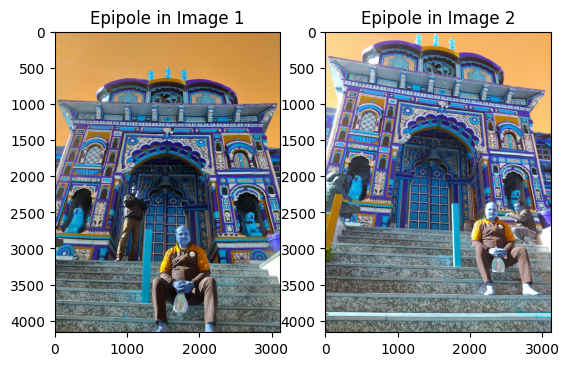

In [ ]:

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the images
img1 = cv2.imread('/content/sample_data/EP1.jpg')
img2 = cv2.imread('/content/sample_data/EP2.jpg')
img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# Step 1: Manually select corresponding points
# Points should be in homogeneous coordinates (x, y, 1)
points1 = np.array([
    [100, 150],  # Point 1 in Image 1
    [200, 220],  # Point 2 in Image 1
    [300, 400],  # Point 3 in Image 1
    [450, 320],  # Point 4 in Image 1
    [120, 500],  # Point 5 in Image 1
    [600, 200],  # Point 6 in Image 1
    [350, 600],  # Point 7 in Image 1
    [500, 450],  # Point 8 in Image 1
])

points2 = np.array([
    [110, 140],  # Point 1 in Image 2
    [210, 210],  # Point 2 in Image 2
    [310, 390],  # Point 3 in Image 2
    [460, 310],  # Point 4 in Image 2
    [130, 490],  # Point 5 in Image 2
    [610, 190],  # Point 6 in Image 2
    [360, 590],  # Point 7 in Image 2
    [510, 440],  # Point 8 in Image 2
])

# Convert points to homogeneous coordinates
points1_h = np.hstack((points1, np.ones((points1.shape[0], 1))))
points2_h = np.hstack((points2, np.ones((points2.shape[0], 1))))

# Step 2: Compute the Fundamental Matrix (using RANSAC for robustness)
F, mask = cv2.findFundamentalMat(points1, points2, cv2.FM_RANSAC)
print("Fundamental Matrix:\n", F)

# Step 3: Plot epipolar lines

def draw_epipolar_lines(img1, img2, F, points1, points2):
    """Draw epipolar lines on both images."""
    lines1 = cv2.computeCorrespondEpilines(points2.reshape(-1, 1, 2), 2, F).reshape(-1, 3)
    lines2 = cv2.computeCorrespondEpilines(points1.reshape(-1, 1, 2), 1, F).reshape(-1, 3)

    # Draw lines on image 1
    img1_lines = img1.copy()
    for r in lines1:
        x0, y0 = map(int, [0, -r[2] / r[1]])
        x1, y1 = map(int, [img1.shape[1], -(r[2] + r[0] * img1.shape[1]) / r[1]])
        img1_lines = cv2.line(img1_lines, (x0, y0), (x1, y1), (255, 0, 0), 1)

    # Draw lines on image 2
    img2_lines = img2.copy()
    for r in lines2:
        x0, y0 = map(int, [0, -r[2] / r[1]])
        x1, y1 = map(int, [img2.shape[1], -(r[2] + r[0] * img2.shape[1]) / r[1]])
        img2_lines = cv2.line(img2_lines, (x0, y0), (x1, y1), (255, 0, 0), 1)

    return img1_lines, img2_lines

img1_lines, img2_lines = draw_epipolar_lines(img1, img2, F, points1, points2)
plt.subplot(121), plt.imshow(img1_lines), plt.title('Epipolar Lines in Image 1')
plt.subplot(122), plt.imshow(img2_lines), plt.title('Epipolar Lines in Image 2')
plt.show()

# Step 4: Compute and show epipoles
def compute_epipoles(F):
    """Compute the epipoles for the fundamental matrix."""
    U, S, Vt = np.linalg.svd(F)
    e1 = Vt[-1] / Vt[-1][-1]  # Right null space of F
    U, S, Vt = np.linalg.svd(F.T)
    e2 = Vt[-1] / Vt[-1][-1]  # Right null space of F.T
    return e1, e2

e1, e2 = compute_epipoles(F)
print("Epipole in Image 1:", e1)
print("Epipole in Image 2:", e2)

# Plot epipoles on the images
img1_epipole = img1.copy()
img2_epipole = img2.copy()
cv2.circle(img1_epipole, (int(e1[0]), int(e1[1])), 10, (0, 255, 0), -1)
cv2.circle(img2_epipole, (int(e2[0]), int(e2[1])), 10, (0, 255, 0), -1)

plt.subplot(121), plt.imshow(img1_epipole), plt.title('Epipole in Image 1')
plt.subplot(122), plt.imshow(img2_epipole), plt.title('Epipole in Image 2')
plt.show()





